In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

# This opens a file upload dialog box
uploaded = files.upload()


Saving viewing_activity.xlsx to viewing_activity.xlsx
Saving user_profile.xlsx to user_profile.xlsx
Saving subscription_retention.xlsx to subscription_retention.xlsx
Saving ratings_feedback.xlsx to ratings_feedback.xlsx


In [3]:
from google.colab import files

# This opens a file upload dialog box
uploaded = files.upload()

Saving content_library.xlsx to content_library.xlsx


In [4]:
user_profile = pd.read_excel("user_profile.xlsx")
viewing_activity = pd.read_excel("viewing_activity.xlsx")
subscription_retention = pd.read_excel("subscription_retention.xlsx")
ratings_feedback = pd.read_excel("ratings_feedback.xlsx")
content_library = pd.read_excel("content_library.xlsx")

## **Task 1: Analyze User Ratings and Reviews**

  Age_Group    Rating
0     18-25  3.019025
1     26-35  3.012268
2     36-50  2.994419
3       50+  3.013128


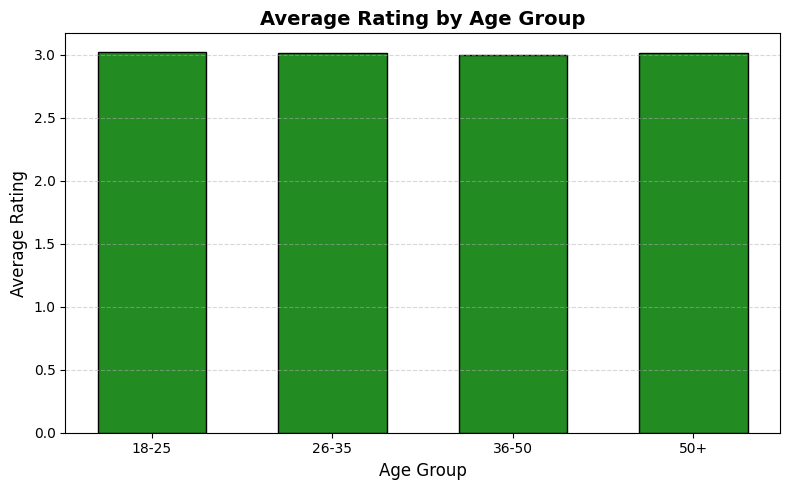

In [8]:

# Analysis 1: Average Rating by Age Group (Vertical Bar Chart)


import pandas as pd
import matplotlib.pyplot as plt

age_rating = pd.merge(
    user_profile[['User_ID', 'Age_Group']],
    ratings_feedback[['User_ID', 'Rating']],
    on='User_ID'
)

# Calculate Average Rating by Age Group
age_summary = (
    age_rating.groupby('Age_Group')['Rating']
    .mean()
    .reindex(['18-25', '26-35', '36-50', '50+'])
    .reset_index()
)

# Display Summary
print(age_summary)

# Create Vertical Bar Chart
plt.figure(figsize=(8,5))

plt.bar(
    age_summary['Age_Group'],
    age_summary['Rating'],
    color='forestgreen',
    edgecolor='black',
    width=0.6
)

plt.title("Average Rating by Age Group", fontsize=14, fontweight='bold')
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

    Region    Rating
0  Central  2.953046
1     East  3.006039
2     West  3.012921
3    South  3.026912
4    North  3.048790


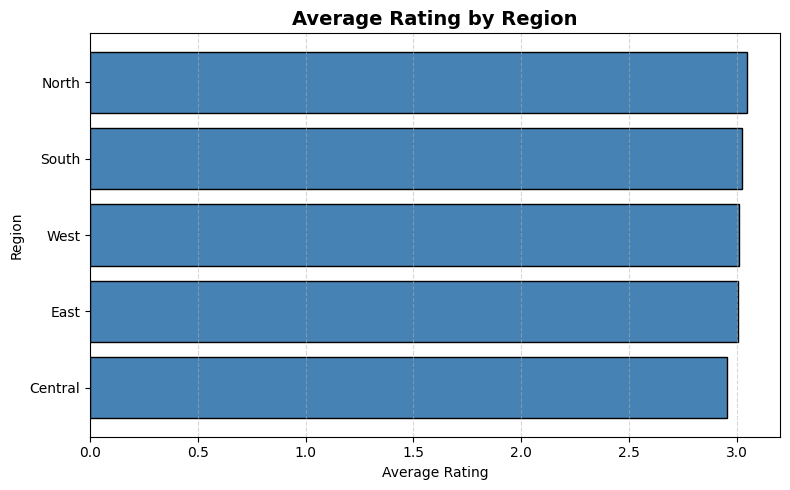

In [11]:

import pandas as pd
import matplotlib.pyplot as plt

# Merge User Profile and Ratings tables
region_rating = pd.merge(
    user_profile[['User_ID', 'Region']],
    ratings_feedback[['User_ID', 'Rating']],
    on='User_ID'
)

# Calculate Average Rating by Region
region_summary = (
    region_rating.groupby('Region')['Rating']
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)

print(region_summary)

# Create Horizontal Bar Chart
plt.figure(figsize=(8,5))

plt.barh(
    region_summary['Region'],
    region_summary['Rating'],
    color='steelblue',
    edgecolor='black'
)

plt.title("Average Rating by Region", fontsize=14, fontweight='bold')
plt.xlabel("Average Rating")
plt.ylabel("Region")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

  Subscription_Type    Rating
0             Basic  3.033384
1        Free Trial  2.990250
2           Premium  3.005643


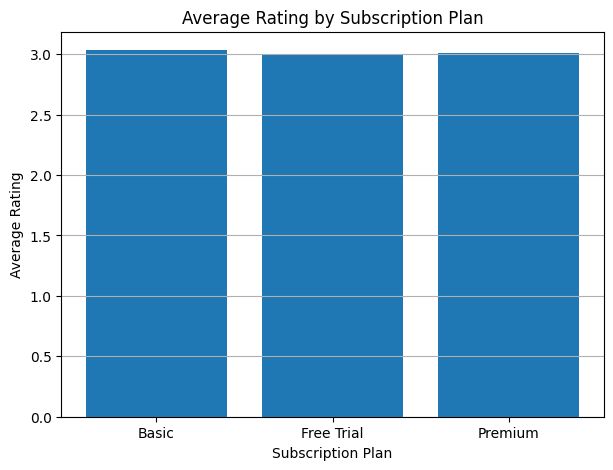

In [ ]:

# Analysis 3 :Average Rating by Subscription Plan

plan_rating = pd.merge(
    user_profile[['User_ID', 'Subscription_Type']],
    ratings_feedback[['User_ID', 'Rating']],
    on='User_ID'
)

plan_summary = (
    plan_rating.groupby('Subscription_Type')['Rating']
    .mean()
    .reset_index()
)

print(plan_summary)

plt.figure(figsize=(7,5))
plt.bar(plan_summary['Subscription_Type'], plan_summary['Rating'])
plt.title('Average Rating by Subscription Plan')
plt.xlabel('Subscription Plan')
plt.ylabel('Average Rating')
plt.grid(axis='y')
plt.show()

**Interpretation :- The analysis suggests that understanding customer ratings across different user groups helps improve customer satisfaction, enhance service quality, and support better business decisions.**

# **Task 2: Evaluate Content Completion Behaviour**

  Subscription_Type  Completion_Percentage
0             Basic              52.391414
1        Free Trial              52.074792
2           Premium              52.610824


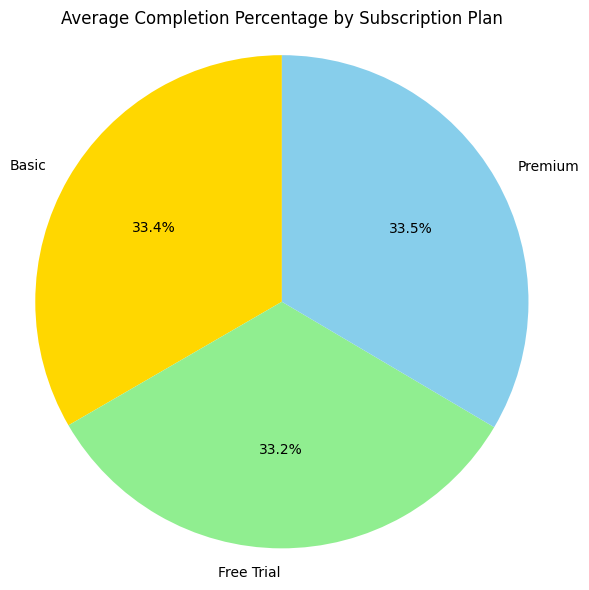

In [17]:


# Analysis 1 : Average Completion Percentage by Subscription Plan


import pandas as pd
import matplotlib.pyplot as plt

# Merge User Profile and Viewing Activity
plan_completion = pd.merge(
    user_profile[['User_ID', 'Subscription_Type']],
    viewing_activity[['User_ID', 'Completion_Percentage']],
    on='User_ID'
)

# Calculate Average Completion Percentage
plan_summary = (
    plan_completion.groupby('Subscription_Type')['Completion_Percentage']
    .mean()
    .reset_index()
)

print(plan_summary)

# Pie Chart
plt.figure(figsize=(7,7))

plt.pie(
    plan_summary['Completion_Percentage'],
    labels=plan_summary['Subscription_Type'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['gold', 'lightgreen', 'skyblue']
)

plt.title("Average Completion Percentage by Subscription Plan")
plt.axis('equal')   # Makes pie chart circular

plt.show()

  Age_Group  Completion_Percentage
0     18-25              52.571291
1     26-35              51.852933
2     36-50              52.597900
3       50+              52.404060


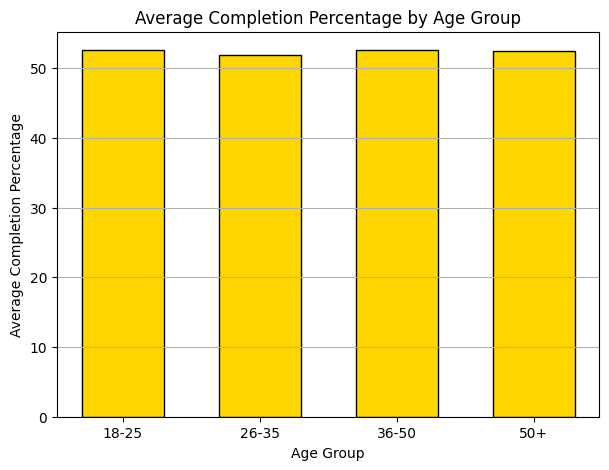

In [21]:

# Analysis 2 :Average Completion Percentage by Age Group


import pandas as pd
import matplotlib.pyplot as plt

# Merge user profile with viewing activity
age_completion = pd.merge(
    user_profile[['User_ID', 'Age_Group']],
    viewing_activity[['User_ID', 'Completion_Percentage']],
    on='User_ID'
)

# Calculate average completion percentage by age group
age_summary = (
    age_completion.groupby('Age_Group')['Completion_Percentage']
    .mean()
    .reset_index()
)

print(age_summary)

# Create Vertical Bar Chart
plt.figure(figsize=(7,5))

plt.bar(
    age_summary['Age_Group'],
    age_summary['Completion_Percentage'],
    color='#FFD700',      # Chrome Yellow (Gold)
    edgecolor='black',
    width=0.6
)

plt.title('Average Completion Percentage by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Completion Percentage')
plt.grid(axis='y')

plt.show()

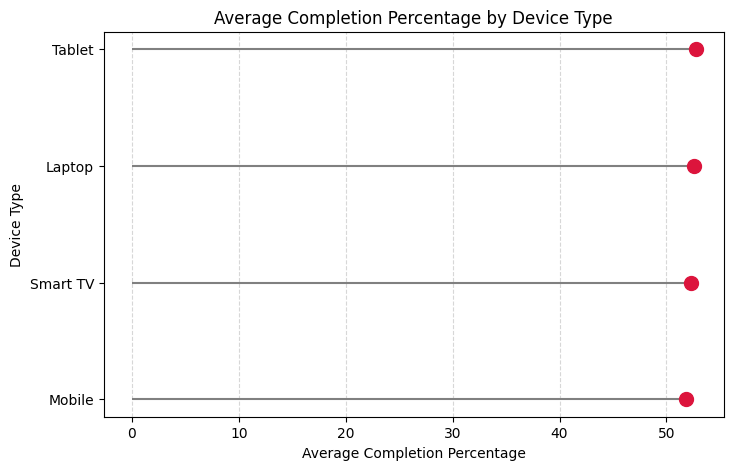

In [12]:

# Analysis 3 : Average Completion Percentage by Device Type


# Analysis 3: Average Completion Percentage by Device Type (Lollipop Chart)

import pandas as pd
import matplotlib.pyplot as plt

device_completion = pd.merge(
    user_profile[['User_ID','Device_Type']],
    viewing_activity[['User_ID','Completion_Percentage']],
    on='User_ID'
)

summary = (
    device_completion.groupby('Device_Type')['Completion_Percentage']
    .mean()
    .sort_values()
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.hlines(
    y=summary['Device_Type'],
    xmin=0,
    xmax=summary['Completion_Percentage'],
    color='gray'
)

plt.plot(
    summary['Completion_Percentage'],
    summary['Device_Type'],
    "o",
    color='crimson',
    markersize=10
)

plt.title("Average Completion Percentage by Device Type")
plt.xlabel("Average Completion Percentage")
plt.ylabel("Device Type")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

**Interpretation :- The analysis suggests that evaluating content completion across different customer groups and devices helps identify viewing preferences, improve content engagement, and support better business decisions.**

# **Task 3: Identify Overall Viewing Behaviour Patterns**

    Region  Watch_Duration_Minutes
0  Central              180.069388
1     East              184.529984
2    North              179.076699
3    South              182.295644
4     West              179.171518


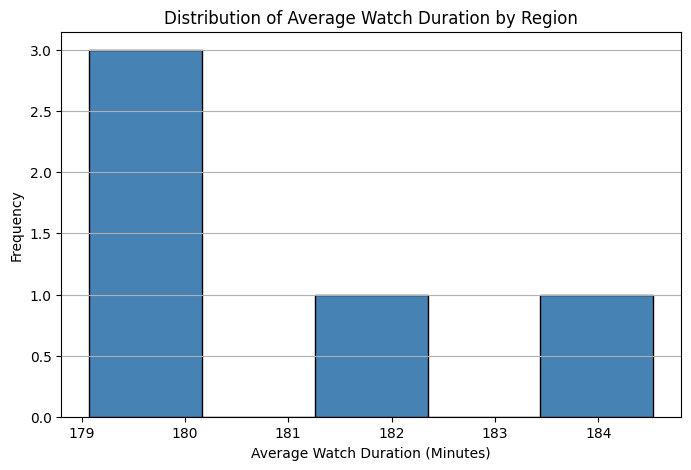

In [19]:
# Analysis 1 : Average Watch Duration by Region


import pandas as pd
import matplotlib.pyplot as plt

region_watch = pd.merge(
    user_profile[['User_ID', 'Region']],
    viewing_activity[['User_ID', 'Watch_Duration_Minutes']],
    on='User_ID'
)

region_summary = (
    region_watch.groupby('Region')['Watch_Duration_Minutes']
    .mean()
    .reset_index()
)

print(region_summary)

plt.figure(figsize=(8,5))

plt.hist(
    region_summary['Watch_Duration_Minutes'],
    bins=5,
    color='steelblue',
    edgecolor='black'
)

plt.title("Distribution of Average Watch Duration by Region")
plt.xlabel("Average Watch Duration (Minutes)")
plt.ylabel("Frequency")
plt.grid(axis='y')

plt.show()

  Device_Type  Watch_Duration_Minutes
0      Laptop              181.163587
1      Mobile              178.833333
2    Smart TV              181.123462
3      Tablet              182.896416


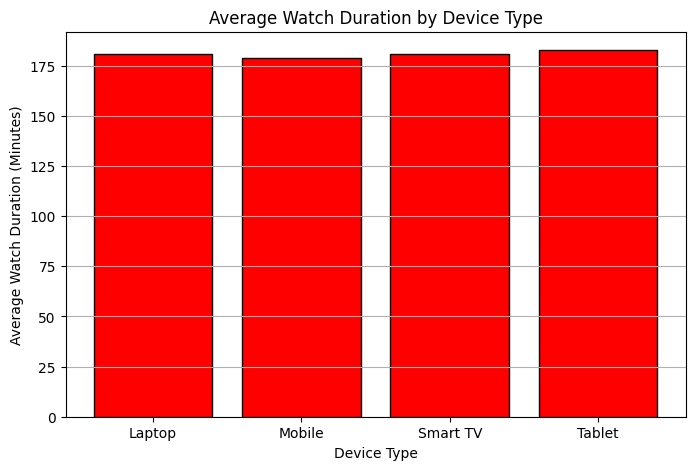

In [20]:


# Analysis 2 : Average Watch Duration by Device Type

device_summary = (
    viewing_activity.groupby('Device_Type')['Watch_Duration_Minutes']
    .mean()
    .reset_index()
)

print(device_summary)

plt.figure(figsize=(8,5))

plt.bar(
    device_summary['Device_Type'],
    device_summary['Watch_Duration_Minutes'],
    color='red',          # Red bars
    edgecolor='black'
)

plt.title('Average Watch Duration by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Average Watch Duration (Minutes)')
plt.grid(axis='y')

plt.show()

  Time_of_Day  Watch_Duration_Minutes
0   Afternoon              180.934453
1     Evening              185.240005
2     Morning              167.317028
3       Night              190.538379


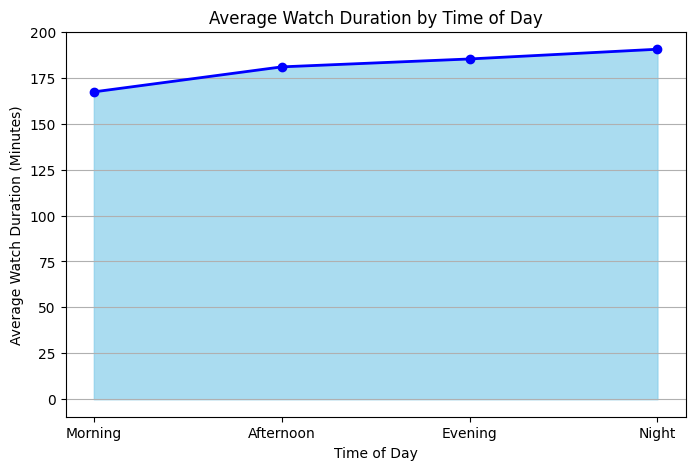

In [18]:

# Analysis 3 : Average Watch Duration by Time of Day


import pandas as pd
import matplotlib.pyplot as plt

# Calculate Average Watch Duration by Time of Day
time_summary = (
    viewing_activity.groupby('Time_of_Day')['Watch_Duration_Minutes']
    .mean()
    .reset_index()
)

print(time_summary)

# Arrange in logical order
order = ['Morning', 'Afternoon', 'Evening', 'Night']
time_summary['Time_of_Day'] = pd.Categorical(
    time_summary['Time_of_Day'],
    categories=order,
    ordered=True
)
time_summary = time_summary.sort_values('Time_of_Day')

# Area Chart
plt.figure(figsize=(8,5))

plt.fill_between(
    time_summary['Time_of_Day'].astype(str),
    time_summary['Watch_Duration_Minutes'],
    color='skyblue',
    alpha=0.7
)

plt.plot(
    time_summary['Time_of_Day'].astype(str),
    time_summary['Watch_Duration_Minutes'],
    color='blue',
    linewidth=2,
    marker='o'
)

plt.title("Average Watch Duration by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Watch Duration (Minutes)")
plt.grid(axis='y')

plt.show()